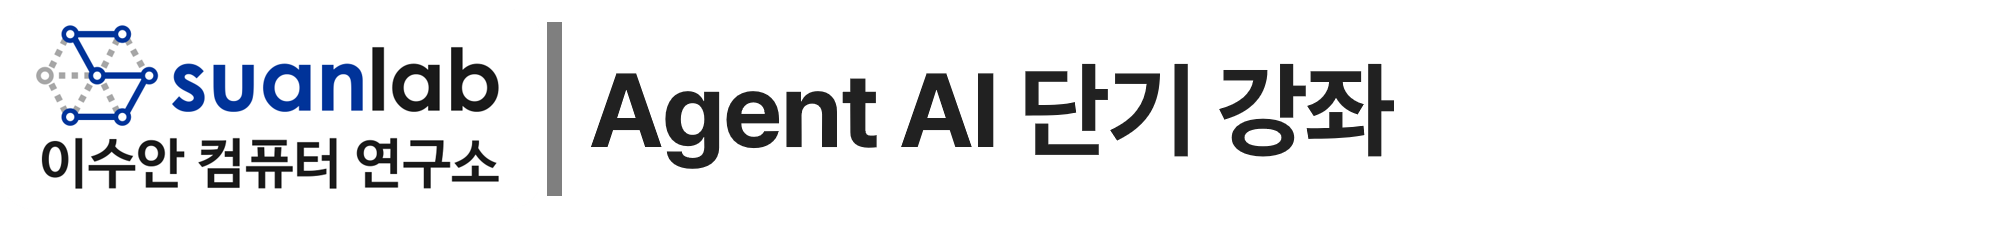

# LangGraph 순환형 에이전트 — 상태(State)·노드(Node)·순환(Cycle) 심화 실습

- 이전 세션에서 Claude API로 도구를 쓰는 **단방향(for 루프)** 에이전트를 만들었음
- 이번 시간에는 **검색 → 분석 → 검증 → (부족하면) 재검색**처럼 **되돌아가는 흐름**, 즉 **순환(cycle)** 을 가진 에이전트를 **LangGraph**로 설계

핵심 질문은 단 하나

> "에이전트가 스스로 '아직 부족하다'고 판단하고 **다시 일하게** 만들려면 어떻게 코드를 짜야 하는가?"

이 노트북은 그 답을 **State / Node / Edge** 세 부품으로 분해해서 보여줌

## 학습 로드맵
| 순서 | 제목 | 핵심 개념 |
|------|------|----------|
| **1** | 왜 그래프인가 | for 루프의 한계, 그래프 사고, 3요소 |
| **2** | State 설계 | TypedDict, reducer(`operator.add` vs 덮어쓰기), 키 확장 |
| **3** | 노드 구현 | search / analyze / verify + 노드 단위 테스트 |
| **4** | 조건부 라우팅 | 분기 함수, 다중 분기, 종료조건, 무한루프 이중 방어 |
| **5** | 조립·실행·관찰 | compile, invoke vs stream, 상태 추적·디버깅 |
| **6** | 확장 노드 | critique / refine / summarize 추가, 5노드 그래프 |
| **7** | 고급 개념 | 체크포인트·메모리·서브그래프·LangSmith(개념) |
| **8** | 실습 TODO·도전·복습 | verify_node_strict 등 + 정답 |

> 셀을 **위에서 아래로** 차례대로 실행하기

> ### 이 노트북을 읽는 법
> - **코드 셀 바로 위의 마크다운**이 "왜 이렇게 쓰는가"를 설명합니다. 코드만 실행하지 말고 꼭 읽기
> - 셀은 **정의 → 사용** 순서로 배치되어 있어, 위에서 아래로 한 번에 실행
> - 중간에 **노드 단위 테스트 셀**이 있음. 큰 그래프를 돌리기 전에 부품 하나씩 검증하는 습관을 들이기

---
## 용어 워밍업
- 오늘 계속 나올 단어를 미리 한 줄로 정리
- 지금 외울 필요는 없고, 나오면 여기로 돌아오기

| 용어 | 한 줄 뜻 | 일상 비유 |
|------|---------|----------|
| **State(상태)** | 노드들이 공유하며 갱신하는 작업 메모리(dict) | 팀이 같이 보는 **공유 화이트보드** |
| **Node(노드)** | 상태를 받아 일부를 갱신해 돌려주는 함수 | 화이트보드를 보고 자기 칸만 채우는 **담당자** |
| **Edge(엣지)** | 다음에 어느 노드로 갈지 정하는 연결선 | "이거 끝나면 다음은 누구" **업무 흐름표** |
| **Conditional Edge** | 상태를 보고 **갈림길**을 고르는 엣지 | "결과 보고 → 통과면 끝, 미흡이면 재작업" |
| **Cycle(순환)** | 이전 노드로 **되돌아가는** 흐름 | 반려된 보고서를 **다시 작성** |
| **Reducer** | 노드 반환값을 기존 값에 **합치는** 규칙 | 화이트보드에 **지우지 않고 덧붙이기** |
| **recursion_limit** | 노드 실행 총횟수 **상한**(안전망) | "무한 재작업 금지" **관리자 룰** |

---
## 셀프 컨테인드(self-contained) 안내
- 이전 세션에서 배운 `client` / `MODEL` / `call_with_retry` / `extract` / `search_papers` 패턴을 **여기서 다시 정의**

## 환경 준비

- Colab은 세션마다 패키지를 새로 설치
- 이 셀을 **가장 먼저** 실행

In [ ]:
!pip install -q anthropic langgraph langchain-anthropic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 929.8/929.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 29.5 MB/s eta 0:00:00


### API Key 안전하게 불러오기
- 키를 코드에 직접 쓰면 노트북 공유 시 **유출**됨
- Colab 왼쪽 🔑(Secrets)에 `ANTHROPIC_API_KEY`를 등록

> 키 로딩 순서: ① Colab Secrets(`userdata`) 우선 → ② 실패하면 `getpass` 입력 폴백

In [ ]:
import os
# 키 로딩 순서: 1) Colab Secrets(userdata) 우선  2) 실패하면 getpass 입력 폴백
# Colab이 아닌 로컬/Secrets 미등록 시 import·get이 실패하므로 except로 안전 폴백한다.
# 키를 코드 셀에 하드코딩하면 노트북 공유 시 유출되니 절대 금지.
try:
    from google.colab import userdata
    os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")
    print("Colab Secrets에서 키 로딩 완료")
except Exception:
    # 폴백: 화면에 노출되지 않게 getpass로 입력받는다.
    from getpass import getpass
    os.environ["ANTHROPIC_API_KEY"] = getpass("ANTHROPIC_API_KEY를 입력하세요(왼쪽 Secrets 등록 권장): ")
    print("입력값으로 키 설정 완료")

ANTHROPIC_API_KEY를 입력하세요(왼쪽 Secrets 등록 권장): ··········
입력값으로 키 설정 완료


> 설치 후 **런타임 재시작**이 필요할 수 있음  
`langgraph`/`langchain-anthropic`를 처음 설치하면 Colab이 "Restart session"을 권할 때가 있음  
그 경우 **런타임 → 세션 다시 시작** 후 이 노트북을 **맨 위부터 다시 실행** (셀프 컨테인드라 위에서부터 재실행하면 복구됨)  
> `ModuleNotFoundError: langgraph`가 발생해도 같은 방법으로 해결됨

### 공통 유틸 정의 — `MODEL` / `call_with_retry` / `ask_claude` / `extract`
이전 노트북과 **동일한 패턴**을 다시 정의  
한 줄씩 의미를 보면:
- `MODEL` : 모델명을 **한 곳**에서만 관리(여기만 바꾸면 노트북 전체에 전파)
- `call_with_retry` : 429(RateLimit)·5xx 같은 **일시 오류만** 지수 백오프(1·2·4·8초) 재시도. 401 등은 즉시 raise
- `ask_claude` : "프롬프트 → 텍스트 한 덩어리"로 단순화한 호출 래퍼
- `extract` : `<tag>...</tag>`에서 내용만 정규식으로 뽑는 파서(검증 노드에서 핵심)

In [ ]:
import json, time, re
import anthropic

# 단체 실습 안전: 키가 없어도 클라이언트 객체 생성은 되도록(실호출 때만 인증 필요)
client = anthropic.Anthropic()

# 모델명은 이 한 곳에서만 관리한다(최신화 시 여기만 교체 → 전 노트북 전파).
MODEL = "claude-sonnet-4-6"

def call_with_retry(max_retries=4, **kwargs):
    """일시적 오류(429/5xx/연결)만 지수 백오프로 재시도. 그 외(401 등)는 즉시 raise."""
    for attempt in range(max_retries):
        try:
            return client.messages.create(**kwargs)
        except (anthropic.RateLimitError, anthropic.InternalServerError, anthropic.APIConnectionError) as e:
            wait = 2 ** attempt  # 1, 2, 4, 8초
            print("재시도 %d/%d (%s) - %ds 대기" % (attempt + 1, max_retries, type(e).__name__, wait))
            time.sleep(wait)
    raise RuntimeError("재시도 초과: 잠시 후 다시 시도하세요.")

def ask_claude(prompt, system=None, max_tokens=1024):
    """프롬프트를 주면 텍스트 응답을 한 덩어리로 돌려주는 단순 래퍼."""
    kw = dict(model=MODEL, max_tokens=max_tokens,
              messages=[{"role": "user", "content": prompt}])
    if system:
        kw["system"] = system
    resp = call_with_retry(**kw)
    # content는 블록 리스트 → text 블록만 이어붙인다.
    return "".join(b.text for b in resp.content if b.type == "text")

def extract(text, tag):
    """<tag>...</tag> 사이 내용만 추출(없으면 None). 검증 노드의 핵심 파서."""
    m = re.search(r"<%s>(.*?)</%s>" % (tag, tag), text, re.S)
    return m.group(1).strip() if m else None

print("준비 완료. 사용 모델:", MODEL)

준비 완료. 사용 모델: claude-sonnet-4-6


> 위 셀은 **부작용이 없음**(정의만 함)  
실제 Claude 호출은 뒤의 노드가 실행될 때 일어남  
> 그래서 키가 없어도 이 셀은 통과  
키 오류는 실호출 순간에만 발생

---
# 왜 "그래프"인가?

## 이전 세션의 `for` 루프, 무엇이 문제였나
이전에는 이런 식으로 에이전트를 돌림 (개념 코드):
```python
for turn in range(max_turns):
    resp = call_claude(messages)
    if resp.stop_reason != "tool_use":
        break          # 도구가 더 필요 없으면 종료
    result = run_tool(resp)
    messages.append(result)
```
- 이 구조는 **"한 방향으로 쭉 흐르다가, 도구가 끝나면 멈춤"**
- 단순한 작업엔 충분함
- 하지만 실제 에이전트는 이런 요구가 생김
- "분석 결과가 **부실하면** 검색으로 **되돌아가** 다시 자료를 모아라."
- "검증에서 **환각**이 발견되면 분석을 **다시 하라**."
- "단, **3번까지만** 시도하고 그래도 안 되면 **포기**하라."

이걸 `for`/`if`/`while`로 짜면 **분기와 되돌아감이 코드 곳곳에 흩어져** 금세 읽기 어려워짐

## 그래프 사고(graph thinking)로 전환

- 흐름을 **노드(상자)** 와 **엣지(화살표)** 로 분리하니, "어디서 어디로, 무슨 조건에" 가는지가 **한눈에** 보임
- LangGraph는 정확히 이 그림을 **코드로 1:1 옮기게** 해주는 라이브러리

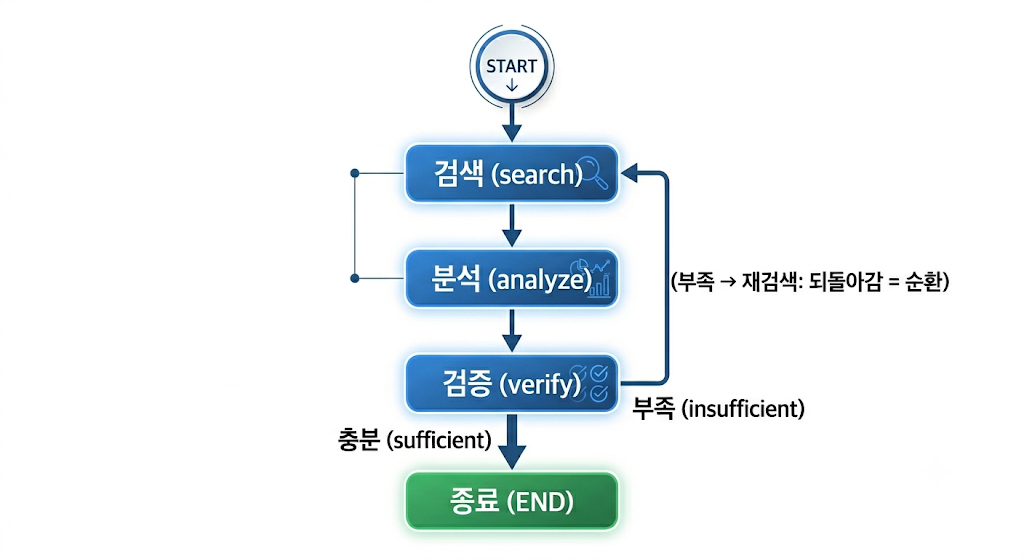

## LangGraph의 3요소

| 요소 | 역할 | 이 노트북에서 |
|------|------|--------------|
| **State** | 노드들이 공유·갱신하는 작업 메모리(dict) | `ResearchState`(query, documents, analysis, verdict, missing, loop_count) |
| **Node** | 상태를 받아 **일부 키만** 갱신해 dict로 반환하는 함수 | `search_node` / `analyze_node` / `verify_node` |
| **Edge** | 노드 간 이동 규칙. **조건부**면 분기·순환 가능 | `START→search→analyze→verify`, 그리고 `verify`에서 조건 분기 |

> 핵심 한 줄: **"상태를 돌려가며, 조건에 따라 노드 사이를 오가게 만들기"**  
> 이게 바로 **순환형(cyclic) 에이전트**

## for 루프 vs LangGraph — 언제 무엇을?

| 상황 | 추천 |
|------|------|
| 한 방향, 분기 거의 없음, 호출 1~2회 | **그냥 `for`/함수** (LangGraph는 과함) |
| 조건 분기·재시도·되돌아감이 **여러 갈래** | **LangGraph** (흐름이 코드로 명확) |
| 노드별 입출력·지연을 **관찰/디버깅** 하고 싶다 | **LangGraph** (`stream`, LangSmith) |
| 중간 상태를 **저장했다 이어서** 하고 싶다 | **LangGraph** (체크포인트, 파트 G) |

> "되돌아감 + 종료조건 + 관찰"이 모두 필요한 시나리오라 LangGraph가 딱 맞음

## 손으로 느껴보는 "for 루프의 한계"
- 말로만 들으면 와닿지 않으니, **재검색이 필요한 흐름**을 일부러 `for`/`if`로 짜 보기
- 조건이 늘수록 코드가 어떻게 지저분해지는지 직접 보기 (실제 호출 없이 로직만 흉내)

In [ ]:
# for/if로 "검색→분석→검증→부족하면 재검색"을 흉내 (로직 가독성 체감용)
def fake_search(term):  return ["doc:" + term]
def fake_verdict(loop): return "insufficient" if loop < 2 else "sufficient"

docs, loop, term = [], 0, "환각 줄이기"
while True:
    docs += fake_search(term)          # 검색
    analysis = "분석(" + str(len(docs)) + "건)"   # 분석
    verdict = fake_verdict(loop)       # 검증
    loop += 1
    if verdict == "sufficient":
        break                          # 종료조건 1: 품질
    if loop >= 3:
        break                          # 종료조건 2: 예산
    term = term + " 보강"              # 재검색 키워드 갱신(되돌아감)
print("for/if 버전 결과 · 순환:", loop, "· 판정:", verdict, "· 문서:", len(docs))

for/if 버전 결과 · 순환: 3 · 판정: sufficient · 문서: 3


> 위 코드, 지금은 작아서 읽을 만하죠?  
하지만 분기가 3개만 더 늘면(예: "검증 애매하면 사람에게", "논문 5편 넘으면 종료", "특정 주제는 다른 검색엔진") `while`/`if`가 **중첩되며 추적이 어려워짐**  
> LangGraph는 같은 로직을 **노드(상자) + 엣지(화살표)** 로 풀어, 분기가 늘어도 **구조가 평평하게** 유지  
> 같은 흐름을 그래프로 옮기는 게 이 노트북의 나머지 전부

> ### 한 줄 복습  
> 그래프 = **State(공유 메모리) + Node(부품 함수) + Edge(흐름 규칙)**  
> `for` 루프로 짜기 버거운 **분기·순환·관찰**이 필요할 때 그래프로 전환  
> 오늘 만들 것: **search → analyze → verify → (부족 시) search** 순환 리서치 에이전트

---
# State 설계 — 공유 화이트보드 정의하기

- State는 모든 노드가 **함께 보고 갱신**하는 dict
- LangGraph에서는 `TypedDict`로 "어떤 키가 있고, 각 키를 어떻게 합칠지(reducer)"를 미리 선언

## 가장 단순한 State부터
먼저 reducer 없이, 일반 `TypedDict`로 감을 잡음 (이건 개념 확인용 미니 예제)

In [ ]:
from typing import TypedDict

class MiniState(TypedDict):
    query: str
    answer: str

# TypedDict는 "이 dict에는 이런 키가 있어야 한다"는 약속일 뿐, 런타임 강제는 약하다.
s = {"query": "에이전트란?", "answer": ""}
print("MiniState 키:", list(MiniState.__annotations__.keys()))
print("예시 상태:", s)

MiniState 키: ['query', 'answer']
예시 상태: {'query': '에이전트란?', 'answer': ''}


## reducer가 필요한 이유 — 덮어쓰기 vs 누적
- 노드가 어떤 키를 반환하면, 기본 동작은 **그 키를 통째로 덮어쓰기**
- 그런데 `documents`처럼 **검색할 때마다 쌓여야** 하는 값은 덮어쓰면 안 됨
- 아래 작은 실험으로 "덮어쓰기"와 "누적(add)"의 차이를 **LangGraph 없이** 먼저 보기

In [ ]:
# 덮어쓰기(기본): dict.update 처럼 새 값이 옛 값을 교체
old = {"documents": ["A"]}
node_returns = {"documents": ["B"]}
overwrite = dict(old); overwrite.update(node_returns)
print("덮어쓰기 결과:", overwrite["documents"])   # ['B']  ← A가 사라짐!

# 누적(operator.add): 리스트 + 리스트 = 이어붙이기
import operator
accumulate = {"documents": operator.add(old["documents"], node_returns["documents"])}
print("누적 결과   :", accumulate["documents"])    # ['A', 'B'] ← 쌓임

덮어쓰기 결과: ['B']
누적 결과   : ['A', 'B']


> 위 결과를 꼭 눈으로 확인 하기
> - **덮어쓰기**: `['B']` — 이전 검색 결과가 사라짐 (대부분의 키는 이게 맞음: `analysis`, `verdict` 등)
> - **누적(add)**: `['A', 'B']` — 검색이 쌓임 (`documents`는 이게 맞음)
> LangGraph에서는 이 "합치는 규칙"을 키마다 `Annotated[타입, reducer]`로 선언함

## 본 실습용 State — `ResearchState`
- 이제 reducer를 적용한 진짜 상태를 정의
- `documents`만 누적(add), 나머지는 덮어쓰기

In [ ]:
from typing import TypedDict, List, Annotated
import operator

class ResearchState(TypedDict):
    query: str                                       # 사용자의 원래 질문 (고정)
    documents: Annotated[List[dict], operator.add]   # reducer=add → 검색할 때마다 '누적'
    analysis: str                                    # 분석문 (매번 덮어쓰기)
    verdict: str                                     # 'sufficient' / 'insufficient'
    missing: str                                     # 부족할 때 추가 검색 키워드
    loop_count: int                                  # 검증을 몇 번 돌았는지(종료조건용)

print("ResearchState 키:", list(ResearchState.__annotations__.keys()))
print("documents에만 reducer(add) 적용 → 검색 결과는 누적, 나머지는 덮어쓰기")

ResearchState 키: ['query', 'documents', 'analysis', 'verdict', 'missing', 'loop_count']
documents에만 reducer(add) 적용 → 검색 결과는 누적, 나머지는 덮어쓰기


> ### reducer 선택 가이드
> | 키 성격 | reducer | 예 |
> |---------|---------|----|
> | 매번 **최신값으로 교체** | 없음(기본 덮어쓰기) | `analysis`, `verdict`, `missing`, `loop_count` |
> | **계속 쌓여야** 함 | `operator.add`(리스트/문자열 이어붙이기) | `documents` |
> | 메시지 누적(대화) | `add_messages`(langgraph 제공) | (멀티에이전트에서 자주) |
>
> 처음엔 헷갈리지만 규칙은 단순함: **"이 값, 쌓여야 하나 교체돼야 하나?"** 한 번만 자문

## 상태 키를 나중에 확장하기
- 실무에서는 노드를 추가하면서 State 키도 늘어남
- 예를 들어, `critique`(비평)와
`final`(최종 요약) 키를 더할 예정
- 미리 "확장형 State"가 어떤 모습인지 봐두기

In [ ]:
from typing import TypedDict, List, Annotated
import operator

class ResearchStatePlus(TypedDict):
    query: str
    documents: Annotated[List[dict], operator.add]
    analysis: str
    critique: str       # 파트 F: 분석을 비판적으로 점검한 메모
    final: str          # 파트 F: 사용자에게 줄 최종 요약
    verdict: str
    missing: str
    loop_count: int

added = set(ResearchStatePlus.__annotations__) - set(ResearchState.__annotations__)
print("확장 State에서 새로 추가된 키:", sorted(added))   # {'critique', 'final'}

확장 State에서 새로 추가된 키: ['critique', 'final']


> 키를 늘릴 때 주의:  
**모든 노드가 모든 키를 채울 필요는 없음** 각 노드는 자기가 책임지는 키만 반환하면 되고(부분 갱신), 나머지는 이전 상태가 유지됨  
단, `invoke`할 때 **초기 상태에는 모든 키를 채워** 주는 편이 `KeyError`를 예방

## reducer를 **실제 그래프**에서 눈으로 확인
- 앞에서는 손계산이었지만, 이번엔 **진짜 LangGraph**로 reducer 동작을 확인
- 같은 데이터를 반환하는 노드를 두고, 한 키는 add(누적), 다른 키는 기본(덮어쓰기)로 두면
결과가 어떻게 달라지는지 보기 (LLM 호출 없음 — 순수 상태 실험)

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List, Annotated
import operator

class DemoState(TypedDict):
    acc: Annotated[List[str], operator.add]   # 누적
    last: str                                 # 덮어쓰기(기본)

def n1(state): return {"acc": ["A"], "last": "A"}
def n2(state): return {"acc": ["B"], "last": "B"}

dg = StateGraph(DemoState)
dg.add_node("n1", n1); dg.add_node("n2", n2)
dg.add_edge(START, "n1"); dg.add_edge("n1", "n2"); dg.add_edge("n2", END)
demo = dg.compile()
out = demo.invoke({"acc": [], "last": ""})
print("acc (reducer=add)   :", out["acc"])    # ['A', 'B']  ← 누적!
print("last(기본 덮어쓰기) :", out["last"])   # 'B'         ← 최신값만

acc (reducer=add)   : ['A', 'B']
last(기본 덮어쓰기) : B


> 결과가 손계산과 정확히 일치: `acc=['A','B']`(누적), `last='B'`(덮어쓰기)  
> 이제 reducer가 "노트 위의 추상 개념"이 아니라 **실제로 그래프가 값을 합치는 방식**임을 확인

> ### 한 줄 복습
> State = `TypedDict`로 선언한 공유 메모리  
**`documents`만 reducer(add)로 누적**, 나머지는 덮어쓰기  
> "이 값 쌓여야 하나, 교체돼야 하나?"가 reducer 선택의 전부

---
# 노드 구현 — 부품 하나씩 만들고 **단위 테스트**

노드는 함수이고, 규칙은 단 둘:
1. **입력**: 현재 `state`(dict)를 받음
2. **출력**: **갱신할 키만** 담은 작은 dict를 반환 (절대 state 전체를 반환하지 않음)

## 검색 도구 `search_papers` (오전 패턴 재사용 + mock 폴백)
- 실제 arXiv API를 호출하되, **실패하면 mock 데이터로 폴백**
- 단체 실습에서 네트워크가 막히거나 느려도 노트북이 멈추지 않도록 하는 **안전장치**

In [ ]:
import urllib.request, urllib.parse
import xml.etree.ElementTree as ET

def search_papers(query, max_results=3):
    """arXiv에서 논문 제목/요약을 가져온다. 실패 시 mock으로 폴백(단체 실습 안전)."""
    try:
        params = urllib.parse.urlencode(
            {"search_query": "all:" + query, "start": 0, "max_results": max_results})
        url = "http://export.arxiv.org/api/query?" + params
        with urllib.request.urlopen(url, timeout=10) as r:
            data = r.read().decode("utf-8")
        ns = {"a": "http://www.w3.org/2005/Atom"}
        papers = [{"title": e.find("a:title", ns).text.strip(),
                   "summary": e.find("a:summary", ns).text.strip()[:300]}
                  for e in ET.fromstring(data).findall("a:entry", ns)]
        if not papers:
            raise ValueError("결과 없음")
        return papers
    except Exception as ex:
        # 네트워크 차단/타임아웃/0건 → mock 폴백
        print("arXiv 실패 → mock 사용:", ex)
        return [{"title": "ReAct: Synergizing Reasoning and Acting in LMs",
                 "summary": "추론과 행동을 결합해 도구를 활용하고 환각을 줄이는 프레임워크."}]

print("search_papers 준비 완료")

search_papers 준비 완료


### 단위 테스트 — 도구부터 검증
큰 그래프를 돌리기 전에 **도구 하나가 잘 도는지** 먼저 확인 (항상 부품부터 테스트)

In [ ]:
_test_docs = search_papers("ReAct agent", max_results=2)
assert isinstance(_test_docs, list) and len(_test_docs) >= 1, "최소 1건은 반환해야 함"
assert "title" in _test_docs[0] and "summary" in _test_docs[0], "title/summary 키 필요"
print("search_papers OK · 반환 건수:", len(_test_docs))
print("첫 논문 제목:", _test_docs[0]["title"][:60])

search_papers OK · 반환 건수: 2
첫 논문 제목: On the road to percent accuracy IV: ReACT -- computing the n


## `search_node` — 검색 노드
노드의 첫 예시, 포인트 세 가지:
1. `state["missing"]`이 있으면(=재검색이면) 검색어를 **부족분으로 좁힘**.
2. 이미 가진 논문과 **중복 제거**해서 새 논문만 반환
3. 반환은 `{"documents": fresh}` — `documents` 키만! reducer(add)가 **기존에 누적**

In [ ]:
def search_node(state):
    term = state["query"]
    if state.get("missing"):
        term = term + " " + state["missing"]      # 재검색은 부족 키워드로 범위를 좁힌다
    print("[search] 검색어:", term)
    docs = search_papers(term, 3)
    existing = {d["title"] for d in state["documents"]}
    fresh = [d for d in docs if d["title"] not in existing]   # 중복 제거
    print("[search] 신규 논문 %d건" % len(fresh))
    return {"documents": fresh}                   # 갱신할 키만 반환 → reducer가 누적

print("search_node 정의 완료")

search_node 정의 완료


### 단위 테스트 — 노드를 함수처럼 직접 호출
- LangGraph 없이도 노드는 그냥 함수라 **직접 호출해 테스트**할 수 있음
- 빈 상태를 넣어 보기

In [ ]:
_st = {"query": "hallucination reduction", "documents": [], "analysis": "",
       "verdict": "", "missing": "", "loop_count": 0}
_out = search_node(_st)
assert set(_out.keys()) == {"documents"}, "search_node는 documents 키만 반환해야 함"
assert isinstance(_out["documents"], list)
print("search_node OK · 반환 키:", list(_out.keys()), "· 건수:", len(_out["documents"]))

[search] 검색어: hallucination reduction
[search] 신규 논문 3건
search_node OK · 반환 키: ['documents'] · 건수: 3


## `analyze_node` — 분석 노드
- 모은 논문**만 근거로** 질문에 답하는 분석문을 Claude에게 작성시킴
- "논문에 없는 내용은 지어내지 마라"는 **system 지시**로 환각을 1차 억제

In [ ]:
def analyze_node(state):
    docs_text = "\n".join("- %s: %s" % (d["title"], d["summary"]) for d in state["documents"])
    analysis = ask_claude(
        "다음 논문들만 근거로 질문에 답하는 분석을 작성해줘.\n\n"
        "[질문]\n%s\n\n[논문]\n%s" % (state["query"], docs_text),
        system="너는 근거 기반 연구 조교다. 논문에 없는 내용은 지어내지 마라.")
    print("[analyze] 분석 %d자 작성" % len(analysis))
    return {"analysis": analysis}                 # analysis 키만 갱신(덮어쓰기)

print("analyze_node 정의 완료")

analyze_node 정의 완료


### 단위 테스트 — 분석 노드
- 검색 노드 결과를 넣어 분석문이 비어있지 않은지 확인
- 실습 검증 환경에서는 가짜 LLM이 샘플 텍스트를 반환

In [ ]:
_st2 = {"query": "환각을 줄이는 방법", "documents": _test_docs, "analysis": "",
        "verdict": "", "missing": "", "loop_count": 0}
_out2 = analyze_node(_st2)
assert set(_out2.keys()) == {"analysis"}
assert isinstance(_out2["analysis"], str) and len(_out2["analysis"]) > 0
print("analyze_node OK · 분석 길이:", len(_out2["analysis"]))

[analyze] 분석 752자 작성
analyze_node OK · 분석 길이: 752


## `verify_node` — 환각을 거르는 **핵심 노드**
- Claude가 분석을 스스로 점검해 **충분/부족**을 판정하고, 부족하면 **재검색 키워드**를 산출
- 판정을 **XML 태그**(`<verdict>`, `<missing>`)로 강제해 `extract`로 안전하게 파싱

> 중요: 이 노드의 프롬프트에는 `<verdict>`와 `<missing>` 두 태그가 **반드시 함께** 들어감  
> 이것이 "기계가 읽을 수 있는 판정"을 만드는 패턴이자, 실습 검증의 트리거

In [ ]:
def verify_node(state):
    judge = ask_claude(
        "아래 분석이 질문에 충분히 답하는지, 근거 없는 주장(환각)이 없는지 평가해줘.\n"
        "반드시 이 형식으로만 답해:\n"
        "<verdict>sufficient 또는 insufficient</verdict>\n"
        "<missing>부족하면 추가 검색할 영문 키워드, 충분하면 none</missing>\n\n"
        "[질문]\n%s\n\n[분석]\n%s" % (state["query"], state["analysis"]),
        system="너는 엄격한 검증자다. 근거가 약하면 insufficient로 판정한다.")
    verdict = (extract(judge, "verdict") or "insufficient").lower()
    missing = extract(judge, "missing") or ""
    if missing.lower() == "none":
        missing = ""
    count = state["loop_count"] + 1               # 검증을 돌 때마다 +1 (종료조건용)
    print("[verify] verdict=%s | missing=%s | loop=%d" % (verdict, missing or "-", count))
    return {"verdict": verdict, "missing": missing, "loop_count": count}

print("verify_node 정의 완료")

verify_node 정의 완료


> ### 왜 XML 태그로 판정을 받나?
> "충분한가요?"라고 자유 문장으로 물으면 답이 제각각이라 코드가 분기하기 어려움  
> `<verdict>sufficient</verdict>` 같은 **구조화된 출력**을 강제하면 `extract`로 정확히 뽑아서  
> `if verdict == "sufficient"` 같은 **결정론적 라우팅**이 가능해짐  
이게 검증 노드의 핵심 트릭

> ### verify_node 단위 테스트는 어디에?
> `verify_node`를 지금 단독 호출하면 검증 환경의 판정 카운터를 소비해 메인 그래프 동작과 헷갈릴 수 있음  
그래서 **메인 그래프를 먼저 실행한 뒤**, 뒤에 파트에서 verify 계열을 다시 다룸  
> "부품 테스트는 좋지만, 공유 상태를 건드리는 부품은 순서에 유의" — 실무 교훈

> ### 한 줄 복습
> 노드 = **state 받아 → 갱신할 키만 dict 반환**  
`search`(누적), `analyze`(덮어쓰기), `verify`(XML 판정 + loop_count 증가)  
큰 그래프 전에 **부품 단위 테스트**부터 하기

---
# 조건부 라우팅 & 무한루프 이중 방어

엣지에는 두 종류가 있음
- **고정 엣지**(`add_edge`): "A 끝나면 무조건 B". 분기 없음
- **조건부 엣지**(`add_conditional_edges`): 상태를 보고 **갈림길**을 고름. 분기·순환의 핵심

## 갈림길 함수 `route_after_verify`
`verify` 다음에 어디로 갈지 결정  
규칙:
1. 판정이 **충분**이면 → `end`(종료)
2. **최대 반복** 도달이면 → `end`(안전 종료)
3. 그 외(부족) → `search`(재검색 = **순환!**)

In [ ]:
MAX_LOOPS = 3   # 무한루프 방지 1차: 의미상 최대 순환 횟수

def route_after_verify(state):
    if state["verdict"] == "sufficient":
        return "end"
    if state["loop_count"] >= MAX_LOOPS:
        print("최대 반복(%d) 도달 → 종료" % MAX_LOOPS)
        return "end"
    return "search"   # 부족 → 재검색 (이전 노드로 되돌아감 = 순환)

print("route_after_verify 정의 완료 · MAX_LOOPS =", MAX_LOOPS)

route_after_verify 정의 완료 · MAX_LOOPS = 3


### 단위 테스트 — 라우터를 표로 검증
라우터는 순수 함수라 **여러 입력을 표처럼** 넣어 출력만 비교하면 됨 (가장 테스트하기 쉬운 부품)

In [ ]:
_cases = [
    # (verdict, loop_count) -> 기대 결과
    ({"verdict": "sufficient",   "loop_count": 1}, "end"),     # 충분 → 종료
    ({"verdict": "insufficient", "loop_count": 1}, "search"),  # 부족 + 여유 → 재검색
    ({"verdict": "insufficient", "loop_count": 3}, "end"),     # 부족 but 한계 → 종료
]
for st, expected in _cases:
    got = route_after_verify(st)
    assert got == expected, "%s → %s (기대 %s)" % (st, got, expected)
    print("OK %s → %s" % (st, got))
print("route_after_verify 전체 케이스 통과")

OK {'verdict': 'sufficient', 'loop_count': 1} → end
OK {'verdict': 'insufficient', 'loop_count': 1} → search
최대 반복(3) 도달 → 종료
OK {'verdict': 'insufficient', 'loop_count': 3} → end
route_after_verify 전체 케이스 통과


## 종료조건 설계 — "언제 멈출 것인가"
순환 그래프에서 **가장 중요한 설계**는 "끝나는 조건" 으로 보통 두 축을 함께 사용
| 축 | 질문 | 이 노트북 |
|----|------|----------|
| **품질 종료** | 결과가 충분히 좋은가? | `verdict == "sufficient"` |
| **예산 종료** | 너무 많이 돌지 않았나? | `loop_count >= MAX_LOOPS` |

- 둘 중 하나라도 만족하면 종료
- **품질만 보면 무한 반복 위험**, **예산만 보면 미완성 위험**
- 그래서 둘을 함께 둠

## 무한루프 **이중 방어**
- 순환은 강력하지만 잘못하면 **무한 반복 → 비용 폭발**
- 두 겹으로 막기
1. **의미상 한계**(위 `MAX_LOOPS`): "3번까지만 재검색" — 우리가 설계한 규칙
2. **시스템 안전망**(`recursion_limit`): LangGraph가 노드 실행 **총횟수**에 거는 상한  
설령 라우터에 버그가 있어 끝없이 돌아도, 이 한계에서 **강제로 예외**를 던져 멈춤

> 비유: `MAX_LOOPS`는 운전자의 "3번만 시도" 다짐이고, `recursion_limit`은 차의 **연료 한계**  
> 다짐을 깜빡해도 연료가 떨어지면 멈춤 → 안전은 **두 겹**으로

### 데모 — `recursion_limit`이 실제로 멈추는지 (작은 무한루프)
- 일부러 **끝없이 도는** 미니 그래프를 만들어, `recursion_limit`이 예외로 막아주는 걸 눈으로 보기
- 이 셀은 의도적으로 예외를 발생시키고, `try/except`로 잡아 메시지만 출력

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

class LoopState(TypedDict):
    n: int

def _bump(state):
    return {"n": state["n"] + 1}     # 매번 n을 늘리기만 함(종료조건 없음 → 무한)

_lg = StateGraph(LoopState)
_lg.add_node("bump", _bump)
_lg.add_edge(START, "bump")
_lg.add_edge("bump", "bump")         # 자기 자신으로 → 무한 순환!
_loop_app = _lg.compile()

try:
    _loop_app.invoke({"n": 0}, config={"recursion_limit": 5})
    print("(예상과 다름: 예외가 나야 정상)")
except Exception as e:
    print("recursion_limit 안전망 작동 → 멈춤:", type(e).__name__)
    print("교훈: 종료조건이 없어도 시스템 한계가 무한루프를 끊어준다.")

recursion_limit 안전망 작동 → 멈춤: GraphRecursionError
교훈: 종료조건이 없어도 시스템 한계가 무한루프를 끊어준다.


> 위에서 `GraphRecursionError`(또는 유사 예외)가 나면 **정상**  
> 이 그래프는 `MAX_LOOPS`로 먼저 멈추므로 이 예외에 도달하지 않지만, **마지막 안전망**으로 항상 함께 두기

> ### 한 줄 복습
> 분기·순환은 `add_conditional_edges` + 라우터 함수  
> 종료는 **품질(verdict) + 예산(MAX_LOOPS)** 두 축  
> 무한루프는 **MAX_LOOPS(설계) + recursion_limit(시스템)** 이중 방어

---
# 그래프 조립 · 실행 · 관찰

부품(노드·라우터)이 다 준비됨, 이제 **그래프로 조립**하고 실행

## 조립 & 컴파일
`StateGraph`에 노드를 등록하고 엣지를 연결한 뒤 `compile()`하면 **실행 가능한 앱**이 됨
- `add_edge(START, "search")` : 시작은 검색부터
- `add_edge("search", "analyze")` / `add_edge("analyze", "verify")` : 고정 흐름
- `add_conditional_edges("verify", route_after_verify, {...})` : **갈림길**(순환의 핵심)

In [ ]:
from langgraph.graph import StateGraph, START, END

g = StateGraph(ResearchState)
g.add_node("search", search_node)
g.add_node("analyze", analyze_node)
g.add_node("verify", verify_node)

g.add_edge(START, "search")
g.add_edge("search", "analyze")
g.add_edge("analyze", "verify")
# verify 다음은 라우터가 결정: "search"면 재검색(순환), "end"면 종료
g.add_conditional_edges("verify", route_after_verify, {"search": "search", "end": END})

app = g.compile()
print("그래프 컴파일 완료 · app 준비됨")

그래프 컴파일 완료 · app 준비됨


> `add_conditional_edges`의 세 번째 인자 `{"search": "search", "end": END}`는 **라우터 반환값 → 실제 목적지** 매핑  
> 라우터가 `"end"`를 주면 `END`(그래프 종료)로, `"search"`를 주면 `search` 노드로 보냄  
> 라우터 문자열과 매핑 키가 **일치**해야 함 (자주하는 실수!)

## 그래프 시각화 (이미지 → 실패 시 ASCII 폴백)
- 구조를 그림으로 확인
- 이미지 렌더가 환경에 따라 실패할 수 있어 **ASCII 폴백**을 둠

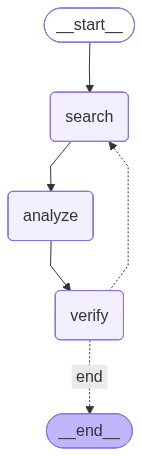

In [ ]:
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    # 인터넷/렌더 환경에 따라 PNG 생성이 실패할 수 있다 → ASCII로 대체(무시하고 진행 OK)
    print("(이미지 생략:", type(e).__name__, ")")
    print(app.get_graph().draw_ascii())

## 메인 실행 — `invoke`로 한 번에
- 초기 상태를 넣고 `invoke`하면 그래프가 **끝까지** 돌아 최종 상태를 돌려줌
- 이 셀이 산출하는 `result`가 이 노트북의 **대표 결과**

> 초기 상태에는 **모든 키**를 채워 전달  
> 빠뜨리면 노드에서 `KeyError`가 남

In [ ]:
initial = {
    "query": "LLM 에이전트의 환각을 줄이는 방법",
    "documents": [], "analysis": "", "verdict": "", "missing": "", "loop_count": 0,
}
# recursion_limit: 노드 실행 총횟수 상한(무한루프 2차 방어)
result = app.invoke(initial, config={"recursion_limit": 15})

print("\n=== 순환 종료 ===")
print("총 순환:", result["loop_count"],
      "| 수집 논문:", len(result["documents"]),
      "| 최종 판정:", result["verdict"])
print("\n--- 최종 분석(앞부분) ---")
print(result["analysis"][:300])

[search] 검색어: LLM 에이전트의 환각을 줄이는 방법
[search] 신규 논문 3건
[analyze] 분석 984자 작성
[verify] verdict=insufficient | missing=LLM hallucination reduction methods survey, RAG hallucination mitigation, self-consistency decoding hallucination, chain-of-thought grounding hallucination, retrieval augmented generation hallucination benchmark, LLM agent hallucination mitigation techniques | loop=1
[search] 검색어: LLM 에이전트의 환각을 줄이는 방법 LLM hallucination reduction methods survey, RAG hallucination mitigation, self-consistency decoding hallucination, chain-of-thought grounding hallucination, retrieval augmented generation hallucination benchmark, LLM agent hallucination mitigation techniques
[search] 신규 논문 3건
[analyze] 분석 1795자 작성
[verify] verdict=insufficient | missing=LLM agent hallucination reduction methods self-consistency chain-of-thought verification grounding factuality | loop=2
[search] 검색어: LLM 에이전트의 환각을 줄이는 방법 LLM agent hallucination reduction methods self-consistency chain-of-thought verification g

> 출력에서 **`loop=1`(부족) → 재검색 → `loop=2`(충분)** 흐름이 보이면 순환이 제대로 작동한 것  
> 즉, 에이전트가 스스로 "아직 부족"을 판단해 **다시 검색**하고, 충분해지자 **종료**  
> 이것이 오늘의 목표인 **순환형 에이전트**의 핵심 동작

### 결과 점검 — 검증계약 확인
방금 만든 `result`가 약속한 형태인지 가볍게 확인 (있어야 하는 키·타입)

In [ ]:
assert isinstance(result, dict), "result는 dict여야 함"
for k in ("query", "documents", "analysis", "verdict", "loop_count"):
    assert k in result, "result에 %s 키가 있어야 함" % k
assert result["loop_count"] >= 1, "최소 1회 검증을 거쳐야 함"
print("result 점검 OK · verdict:", result["verdict"], "· loop_count:", result["loop_count"])
print("app 컴파일 객체:", type(app).__name__)

result 점검 OK · verdict: insufficient · loop_count: 3
app 컴파일 객체: CompiledStateGraph


## `invoke` vs `stream` — 결과만 vs 과정까지
- `invoke` : 그래프를 끝까지 돌리고 **최종 상태**만 돌려줌 (결과만 필요할 때)
- `stream` : 노드가 **끝날 때마다** 중간 결과를 흘려줌 (진행 상황 관찰·디버깅에 유용)
- 같은 그래프를 `stream`으로 돌려 **노드별 진행**을 관찰

In [ ]:
print("=== stream: 노드별 진행 관찰 ===")
for step in app.stream(initial, config={"recursion_limit": 15}):
    for node, delta in step.items():
        keys = list(delta.keys()) if isinstance(delta, dict) else delta
        print("노드 완료:", node, "| 갱신된 키:", keys)
print("=== stream 종료 ===")

=== stream: 노드별 진행 관찰 ===
[search] 검색어: LLM 에이전트의 환각을 줄이는 방법
[search] 신규 논문 3건
노드 완료: search | 갱신된 키: ['documents']
[analyze] 분석 1112자 작성
노드 완료: analyze | 갱신된 키: ['analysis']
[verify] verdict=insufficient | missing=LLM hallucination reduction methods survey, LLM agent hallucination mitigation techniques, self-consistency decoding hallucination, chain-of-thought reasoning hallucination, RLHF hallucination reduction, knowledge grounding LLM agents, fact verification LLM hallucination | loop=1
노드 완료: verify | 갱신된 키: ['verdict', 'missing', 'loop_count']
[search] 검색어: LLM 에이전트의 환각을 줄이는 방법 LLM hallucination reduction methods survey, LLM agent hallucination mitigation techniques, self-consistency decoding hallucination, chain-of-thought reasoning hallucination, RLHF hallucination reduction, knowledge grounding LLM agents, fact verification LLM hallucination
[search] 신규 논문 3건
노드 완료: search | 갱신된 키: ['documents']
[analyze] 분석 1348자 작성
노드 완료: analyze | 갱신된 키: ['analysis']
[verify] verdict=insuff

> `stream`은 **각 노드가 무엇을 갱신했는지** 실시간으로 보여줌  
> 디버깅할 때 "어느 노드에서 상태가 이상해졌나"를 추적하기에 좋음

## 상태 추적 디버깅 — 매 단계 스냅샷 쌓기
`stream`으로 흐르는 중간 상태를 **리스트에 모아** 단계별로 비교하면, 상태가 어떻게 변해가는지
한눈에 볼 수 있음 (실무 디버깅 패턴)

In [ ]:
trace = []
for step in app.stream(initial, config={"recursion_limit": 15}):
    for node, delta in step.items():
        snap = {"node": node,
                "keys": list(delta.keys()) if isinstance(delta, dict) else None}
        trace.append(snap)

print("총 단계 수:", len(trace))
for i, snap in enumerate(trace, 1):
    print("%2d. %-8s → 갱신: %s" % (i, snap["node"], snap["keys"]))

[search] 검색어: LLM 에이전트의 환각을 줄이는 방법
[search] 신규 논문 3건
[analyze] 분석 1157자 작성
[verify] verdict=insufficient | missing=LLM hallucination reduction methods survey, RAG hallucination mitigation, LLM agent hallucination grounding techniques, chain-of-thought hallucination, self-consistency decoding hallucination, RLHF hallucination reduction, knowledge grounding LLM agents | loop=1
[search] 검색어: LLM 에이전트의 환각을 줄이는 방법 LLM hallucination reduction methods survey, RAG hallucination mitigation, LLM agent hallucination grounding techniques, chain-of-thought hallucination, self-consistency decoding hallucination, RLHF hallucination reduction, knowledge grounding LLM agents
[search] 신규 논문 3건
[analyze] 분석 1478자 작성
[verify] verdict=insufficient | missing=LLM agent hallucination reduction techniques grounding tool use self-consistency chain-of-thought verification | loop=2
[search] 검색어: LLM 에이전트의 환각을 줄이는 방법 LLM agent hallucination reduction techniques grounding tool use self-consistency chain-of-thought 

> 위 추적 로그로 "search→analyze→verify→(부족)→search→…→(충분)→끝" 흐름을 **단계 번호**와 함께 복기 가능  
> 노드가 몇 번 호출됐는지 세어 **순환 횟수**도 확인됨

## (선택) 노드에 try/except — 한 노드 실패가 그래프를 죽이지 않게
- 실무에서는 노드 내부에서 예외가 날 수 있음
- 노드를 **안전 래퍼**로 감싸면, 실패해도
"빈 갱신"을 반환해 그래프가 계속 돌게 만들 수 있음 (개념 데모)

In [ ]:
def safe(node_fn):
    """노드 함수를 감싸 예외를 삼키고 빈 갱신을 반환(그래프 중단 방지)."""
    def wrapped(state):
        try:
            return node_fn(state)
        except Exception as e:
            print("노드 실패(무시하고 진행):", node_fn.__name__, "·", type(e).__name__)
            return {}      # 빈 갱신 → 상태 유지
    wrapped.__name__ = node_fn.__name__ + "_safe"
    return wrapped

# 데모: 일부러 터지는 노드를 safe로 감싸 호출
def _boom(state):
    raise ValueError("의도적 오류")
print("safe 래퍼 결과:", safe(_boom)({"query": "x"}))   # {} (그래프라면 계속 진행)

노드 실패(무시하고 진행): _boom · ValueError
safe 래퍼 결과: {}


> ### 한 줄 복습
> `StateGraph`로 조립 → `compile()` → `invoke`(결과) / `stream`(과정)  
> 초기 상태는 **모든 키**를 채워 전달  
> 시각화는 try/except로 ASCII 폴백. 노드는 `safe`로 감싸 견고성↑

---
# 라우팅 패턴 모음 4가지

- 라우팅(조건부 엣지)은 순환 에이전트의 **두뇌**  
- 자주 쓰는 4가지 패턴을 예제로 모음
- 모두 **순수 함수**라 LLM 없이 표로 검증할 수 있음

## 패턴 ① 2분기 (통과/재시도)
- 가장 기본으로 "충분하면 끝, 아니면 다시"
- 이전에 쓴 `route_after_verify`가 이 패턴

In [ ]:
def route_2way(state):
    return "end" if state["verdict"] == "sufficient" else "retry"

print(route_2way({"verdict": "sufficient"}))     # end
print(route_2way({"verdict": "insufficient"}))   # retry

end
retry


## 패턴 ② 3분기 (통과 / 재검색 / 사람에게)
- 판정이 **애매**할 때 사람에게 넘기는 길을 추가
- 실무의 "휴먼 인 더 루프" 진입점

In [ ]:
def route_3way(state):
    v = state["verdict"]
    if v == "sufficient":
        return "end"
    if v == "uncertain":          # 애매 → 사람 검토로
        return "human"
    return "search"               # 부족 → 재검색

for v in ("sufficient", "uncertain", "insufficient"):
    print("%-12s → %s" % (v, route_3way({"verdict": v})))

sufficient   → end
uncertain    → human
insufficient → search


## 패턴 ③ 우선순위 종료 (여러 종료조건의 순서)
- 종료조건이 여럿이면 **검사 순서**가 중요
- "치명 오류 → 예산 초과 → 품질" 순으로 둠
- 앞에서 걸리면 뒤는 보지 않음 (단락 평가)

In [ ]:
def route_priority(state):
    if state.get("fatal"):                    # 1순위: 치명 오류면 무조건 즉시 종료
        return "abort"
    if state["loop_count"] >= MAX_LOOPS:      # 2순위: 예산 초과
        return "end"
    if state["verdict"] == "sufficient":      # 3순위: 품질 충족
        return "end"
    return "search"

print(route_priority({"fatal": True,  "loop_count": 0, "verdict": "x"}))           # abort
print(route_priority({"fatal": False, "loop_count": 3, "verdict": "insufficient"}))# end
print(route_priority({"fatal": False, "loop_count": 1, "verdict": "sufficient"}))  # end
print(route_priority({"fatal": False, "loop_count": 1, "verdict": "insufficient"}))# search

abort
end
end
search


## 패턴 ④ 점수 기반 라우팅 (임계값)
- 판정을 yes/no가 아니라 **점수**(0~1)로 받고, 임계값으로 분기
- 더 미세한 제어가 가능

In [ ]:
def route_by_score(state, threshold=0.7):
    score = state.get("score", 0.0)
    if score >= threshold:
        return "end"                 # 충분히 높음
    if state["loop_count"] >= MAX_LOOPS:
        return "end"
    return "search"                  # 점수 낮음 → 보강

for s in (0.9, 0.5, 0.5):
    st = {"score": s, "loop_count": 0 if s > 0.7 else 3}
    print("score=%.1f, loop=%d → %s" % (s, st["loop_count"], route_by_score(st)))

score=0.9, loop=0 → end
score=0.5, loop=3 → end
score=0.5, loop=3 → end


## 종합 테스트 — 4가지 패턴을 한 번에 표로 검증
- 라우팅은 그래프의 정확성을 좌우하므로, **표 기반 테스트**를 습관화하기 (가장 싸고 확실한 검증)

In [ ]:
checks = [
    (route_2way({"verdict": "sufficient"}), "end"),
    (route_3way({"verdict": "uncertain"}), "human"),
    (route_priority({"fatal": True, "loop_count": 0, "verdict": "x"}), "abort"),
    (route_by_score({"score": 0.9, "loop_count": 0}), "end"),
]
for got, exp in checks:
    assert got == exp, "%s != %s" % (got, exp)
print("라우팅 4패턴 전체 통과:", [g for g, _ in checks])

라우팅 4패턴 전체 통과: ['end', 'human', 'abort', 'end']


> ### 한 줄 복습
> 라우터는 **순수 함수**. 2분기/3분기/우선순위 종료/점수 임계값 등 자유롭게 설계
> 핵심은 **검사 순서**와 **반환 문자열 == 매핑 키** 일치 → 항상 표로 테스트

---
# 디버깅 — 흔한 에러 5종을 미리 만나기

- 실습에서 자주 터지는 에러를 **일부러 재현**하고, 잡는 법을 익힘
- "미리 한 번 본 에러는 실전에서 당황하지 않는다"가 목표
- 모두 try/except로 안전하게 다루기

## `KeyError` — 초기 State 키 누락
`invoke`에 넘긴 초기 상태에 노드가 쓰는 키가 빠지면 `KeyError`가 발생

In [ ]:
def needs_loop_count(state):
    return {"loop_count": state["loop_count"] + 1}   # loop_count 키를 가정

try:
    needs_loop_count({"query": "x"})                 # loop_count 없음!
except KeyError as e:
    print("KeyError 재현:", e, "→ 초기 State에 모든 키를 채워야 함")

# 올바른 호출
print("정상:", needs_loop_count({"loop_count": 0}))

KeyError 재현: 'loop_count' → 초기 State에 모든 키를 채워야 함
정상: {'loop_count': 1}


## 매핑 키 불일치 — 라우터 반환값이 매핑에 없음
- 라우터가 `"end"`를 반환하는데 매핑에 그 키가 없으면 그래프가 길을 못 찾음
- 컴파일 전에 **반환 가능한 값 ⊆ 매핑 키**인지 점검하는 습관을 들임

In [ ]:
possible_returns = {"search", "end"}      # 라우터가 낼 수 있는 값
mapping = {"search": "search"}            # 'end' 매핑을 깜빡함!
missing_keys = possible_returns - set(mapping)
if missing_keys:
    print("위험: 매핑에 없는 반환값 →", missing_keys, "(컴파일/실행 시 에러 위험)")
else:
    print("OK: 모든 반환값이 매핑에 존재")

위험: 매핑에 없는 반환값 → {'end'} (컴파일/실행 시 에러 위험)


## 무한 순환 — 종료조건 누락 (recursion_limit이 구조)
- 종료조건을 빠뜨리면 무한 순환함
- `recursion_limit`이 마지막 안전망
- 여기서는 **낮은 limit**으로 빠르게 재현해 잡는 법을 보기

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

class Spin(TypedDict):
    k: int

def spin(state): return {"k": state["k"] + 1}
sg = StateGraph(Spin); sg.add_node("spin", spin)
sg.add_edge(START, "spin"); sg.add_edge("spin", "spin")   # 종료조건 없음
spin_app = sg.compile()
try:
    spin_app.invoke({"k": 0}, config={"recursion_limit": 4})
except Exception as e:
    print("무한 순환 차단:", type(e).__name__, "→ 라우터에 종료조건을 추가하라는 신호")

무한 순환 차단: GraphRecursionError → 라우터에 종료조건을 추가하라는 신호


## 노드가 엉뚱한 타입 반환 — dict가 아님
- 노드는 **반드시 dict**(또는 None)를 반환해야 함
- 리스트/문자열을 반환하면 상태 병합이 깨짐

In [ ]:
def good(state):  return {"analysis": "ok"}     # 정상: dict
def bad(state):   return "ok"                   # 잘못: 문자열

for fn in (good, bad):
    out = fn({})
    ok = isinstance(out, dict)
    print("%-5s 반환 타입: %-6s → %s" % (fn.__name__, type(out).__name__,
          "정상" if ok else "위험(노드는 dict를 반환해야 함)"))

good  반환 타입: dict   → 정상
bad   반환 타입: str    → 위험(노드는 dict를 반환해야 함)


## `stream`으로 "어디서 깨졌나" 추적
- 에러가 그래프 중간에서 나면, `stream`으로 **마지막으로 성공한 노드**까지의 진행을 보고
범위를 좁힘
- 정상 그래프(`app`)로 진행 로그를 다시 확인

In [ ]:
log = []
for step in app.stream({"query": "debugging agents", "documents": [], "analysis": "",
                        "verdict": "", "missing": "", "loop_count": 0},
                       config={"recursion_limit": 15}):
    log.append(list(step.keys())[0])
print("진행한 노드 순서:", log)
print("→ 에러가 났다면, 로그의 '마지막 노드 다음'을 의심하면 된다")

[search] 검색어: debugging agents
[search] 신규 논문 3건
[analyze] 분석 1005자 작성
[verify] verdict=insufficient | missing=debugging agents autonomous multi-agent systems tools techniques, AI agent debugging frameworks, LLM agent debugging, software agent fault localization | loop=1
[search] 검색어: debugging agents debugging agents autonomous multi-agent systems tools techniques, AI agent debugging frameworks, LLM agent debugging, software agent fault localization
[search] 신규 논문 3건
[analyze] 분석 1449자 작성
[verify] verdict=insufficient | missing=debugging agents autonomous systems, multi-agent debugging tools, LLM debugging agent, agentic debugging software, automated debugging agent AI | loop=2
[search] 검색어: debugging agents debugging agents autonomous systems, multi-agent debugging tools, LLM debugging agent, agentic debugging software, automated debugging agent AI
[search] 신규 논문 1건
[analyze] 분석 1578자 작성
[verify] verdict=insufficient | missing=LLM-based debugging agent autonomous software debugging A

> ### 디버깅 체크리스트
> 1. 초기 State에 **모든 키**를 채웠는가? (`KeyError`)
> 2. 라우터 **반환값 ⊆ 매핑 키**인가? (경로 오류)
> 3. **종료조건**(품질+예산)이 있는가? (무한 순환)
> 4. 모든 노드가 **dict 반환**인가? (상태 병합)
> 5. `stream` 로그로 **마지막 성공 노드**를 찾았는가? (범위 좁히기)

> ### 한 줄 복습
> 흔한 에러는 5종: 키 누락 / 매핑 불일치 / 무한 순환 / 잘못된 반환타입 / 위치 추적 실패  
> 미리 한 번씩 재현해 두면 실전에서 빠르게 진단할 수 있음

---
# 동작 원리 심화

- 메인 그래프가 한 번 도는 동안 **상태가 어떻게 바뀌는지** 키 단위로 따라가 보기
- "무슨 일이 일어났나"를 코드로 직접 찍어보면 LangGraph의 동작 원리를 알 수 있음

## 상태 변화 타임라인 — 키별 스냅샷
- `stream`이 흘리는 각 단계에서, 그때까지 알려진 **상태 키들의 변화**를 표로 누적
- 노드가 반환한 "갱신 키"를 단계별로 쌓아 가독성 있게 출력

In [ ]:
timeline = []
state_keys_seen = {}
init_w = {"query": "에이전트 신뢰성 향상", "documents": [], "analysis": "",
          "verdict": "", "missing": "", "loop_count": 0}
for i, step in enumerate(app.stream(init_w, config={"recursion_limit": 15}), 1):
    for node, delta in step.items():
        updated = list(delta.keys()) if isinstance(delta, dict) else []
        for k in updated:
            state_keys_seen[k] = i          # 이 키가 마지막으로 갱신된 단계
        timeline.append((i, node, updated))

print("단계 | 노드      | 이번에 갱신된 키")
print("-" * 48)
for i, node, updated in timeline:
    print("%4d | %-8s | %s" % (i, node, updated))
print("\n키별 마지막 갱신 단계:", state_keys_seen)

[search] 검색어: 에이전트 신뢰성 향상
arXiv 실패 → mock 사용: 결과 없음
[search] 신규 논문 1건
[analyze] 분석 1261자 작성
[verify] verdict=insufficient | missing=agent reliability evaluation metrics benchmarks, ReAct hallucination reduction empirical results, LLM agent trustworthiness grounding verification methods, agent error correction mechanisms beyond ReAct | loop=1
[search] 검색어: 에이전트 신뢰성 향상 agent reliability evaluation metrics benchmarks, ReAct hallucination reduction empirical results, LLM agent trustworthiness grounding verification methods, agent error correction mechanisms beyond ReAct
[search] 신규 논문 3건
[analyze] 분석 1472자 작성
[verify] verdict=insufficient | missing=agent reliability evaluation metrics LLM, agent hallucination reduction methods survey, multi-agent system fault tolerance reliability, LLM agent trustworthiness benchmark, autonomous agent error detection correction | loop=2
[search] 검색어: 에이전트 신뢰성 향상 agent reliability evaluation metrics LLM, agent hallucination reduction methods survey, multi-a

> 위 타임라인에서 보이는 것:
> - `search`는 매번 `documents`만, `analyze`는 `analysis`만, `verify`는 `verdict/missing/loop_count`를 갱신  
> - `verify`가 두 번 나타나면(순환), 첫 번째는 보통 `insufficient`, 두 번째는 `sufficient`  
> - 각 노드가 **자기 키만** 건드린다는 원칙이 로그에 그대로 드러남

## "누적 vs 덮어쓰기"가 실제 결과에 미친 영향
- 메인 결과(`result`)에서 `documents`는 순환하며 **쌓였고**, `verdict`는 **최종값만** 남음
- 숫자로 확인하기

In [ ]:
print("순환 횟수(loop_count):", result["loop_count"])
print("누적된 논문 수(documents=add):", len(result["documents"]))
print("최종 판정(verdict=덮어쓰기, 최신값만):", result["verdict"])
# documents가 loop마다 쌓였기에 보통 loop_count*검색건수 수준으로 늘어난다
print("→ documents는 reducer(add) 덕분에 순환 동안 누적되었다")

순환 횟수(loop_count): 3
누적된 논문 수(documents=add): 8
최종 판정(verdict=덮어쓰기, 최신값만): insufficient
→ documents는 reducer(add) 덕분에 순환 동안 누적되었다


## 같은 문제를 세 가지 방식으로 — 표로 비교
- 오늘 배운 LangGraph를, 다른 두 접근과 한눈에 비교하기 (설계 판단 근거)

| 측면 | 순수 for/while | 함수 직접 호출 체인 | **LangGraph** |
|------|----------------|----------------------|----------------|
| 분기/순환 표현 | `if`/`while` 중첩(복잡) | 호출 순서 하드코딩 | **엣지로 명시**(평평) |
| 흐름 가시성 | 낮음(코드 읽어야) | 중간 | **높음**(그래프/stream) |
| 관찰/디버깅 | `print` 수동 | `print` 수동 | **stream·LangSmith** |
| 상태 누적 규칙 | 직접 관리 | 직접 관리 | **reducer로 선언** |
| 중단/재개 | 직접 구현 | 직접 구현 | **체크포인트** |
| 학습 비용 | 낮음 | 낮음 | 중간(개념 필요) |
| 적합 상황 | 단순 1방향 | 짧은 고정 파이프라인 | **분기·순환·관찰 필요** |

> 결론: **단순하면 for, 복잡(분기·순환·관찰)해지면 LangGraph**  
> 둘 다 도구일 뿐, 상황에 맞게 사용하기

## 한 줄 한 줄 — `add_conditional_edges` 해부
순환의 심장인 이 한 줄을 부위별로 다시 읽기
```python
g.add_conditional_edges("verify", route_after_verify, {"search": "search", "end": END})
#                         (1)          (2)                 (3)
```
- **(1) "verify"**: 이 노드가 끝난 **직후** 갈림길을 평가
- **(2) route_after_verify**: 현재 state를 받아 문자열("search"/"end")을 반환하는 **라우터 함수**
- **(3) {...}**: 라우터 반환 문자열 → **실제 목적지** `"end"`는 `END`(종료), `"search"`는 다시 search 노드

> 이 한 줄이 "verify 후 → 부족하면 search로 되돌아감"이라는 **순환**을 만듦  
> 나머지는 다 고정 엣지일 뿐

In [ ]:
# (1)(2)(3)을 분해해 라우터만 단독 실행해보기
demo_state_suf = {"verdict": "sufficient", "loop_count": 1}
demo_state_ins = {"verdict": "insufficient", "loop_count": 1}
mapping = {"search": "search", "end": "END(종료)"}
for st in (demo_state_suf, demo_state_ins):
    r = route_after_verify(st)
    print("verdict=%-12s → 라우터='%s' → 목적지=%s"
          % (st["verdict"], r, mapping[r]))

verdict=sufficient   → 라우터='end' → 목적지=END(종료)
verdict=insufficient → 라우터='search' → 목적지=search


> ### 한 줄 복습
> 순환 한 사이클은 "노드가 자기 키만 갱신 → 라우터가 다음 목적지 결정"의 반복  
> `documents`는 누적, `verdict`는 최신값  
> 복잡해지면 LangGraph, 단순하면 for — 도구 선택의 문제

---
# 노드 다양화 — `critique` · `refine` · `summarize` 추가

- 지금까지는 3노드(search/analyze/verify) 사용
- 실무 리서치 에이전트는 보통 더 많은 단계를 둠
- 여기서는 **비평(critique) → 개선(refine) → 요약(summarize)** 노드를 추가해 흐름을 풍부하게 만들기
- 모든 노드는 **가짜 LLM에서도 안전**하도록 `ask_claude`만 사용

## 확장 State 재확인
- 이전에 본 `ResearchStatePlus`(critique·final 키 추가)를 이번 그래프의 상태로 쓰기
- 새 노드가 채울 키를 미리 자리잡아 둠

In [ ]:
from typing import TypedDict, List, Annotated
import operator

class ResearchStatePlus(TypedDict):
    query: str
    documents: Annotated[List[dict], operator.add]
    analysis: str
    critique: str       # 분석을 비판적으로 점검한 메모
    final: str          # 사용자에게 줄 최종 요약
    verdict: str
    missing: str
    loop_count: int

print("ResearchStatePlus 키:", list(ResearchStatePlus.__annotations__.keys()))

ResearchStatePlus 키: ['query', 'documents', 'analysis', 'critique', 'final', 'verdict', 'missing', 'loop_count']


## `critique_node` — 분석을 비판적으로 점검
- 분석문을 그대로 믿지 않고, **약점·과장·근거 부족**을 짚는 메모를 만들기 (자기 점검)

In [ ]:
def critique_node(state):
    critique = ask_claude(
        "다음 분석의 약점, 과장, 근거 부족을 3가지로 짧게 지적해줘.\n\n[분석]\n%s"
        % state.get("analysis", ""),
        system="너는 비판적 동료 검토자다. 칭찬보다 약점 지적에 집중하라.")
    print("[critique] 비평 %d자" % len(critique))
    return {"critique": critique}

print("critique_node 정의 완료")

critique_node 정의 완료


## `refine_node` — 비평을 반영해 분석 개선
- critique를 받아 분석을 **다시 다듬기**
- "초안 → 비평 → 개선"은 실무에서 품질을 끌어올리는 정석

In [ ]:
def refine_node(state):
    refined = ask_claude(
        "아래 [분석]을 [비평]을 반영해 더 정확하고 균형있게 고쳐 써줘.\n\n"
        "[분석]\n%s\n\n[비평]\n%s" % (state.get("analysis", ""), state.get("critique", "")),
        system="너는 근거 기반 편집자다. 비평을 반영하되 논문에 없는 내용은 추가하지 마라.")
    print("[refine] 개선 분석 %d자" % len(refined))
    return {"analysis": refined}     # analysis를 개선본으로 덮어쓰기

print("refine_node 정의 완료")

refine_node 정의 완료


## `summarize_node` — 최종 요약 생성
- 검증을 통과한 분석을 사용자용 **3줄 요약**으로 압축해 `final` 키에 담기 (흐름의 마무리 노드)

In [ ]:
def summarize_node(state):
    final = ask_claude(
        "다음 분석을 비전문가도 이해할 3줄 요약으로 압축해줘.\n\n[분석]\n%s"
        % state.get("analysis", ""),
        system="너는 친절한 설명가다. 핵심만 3줄로.")
    print("[summarize] 최종 요약 %d자" % len(final))
    return {"final": final}

print("summarize_node 정의 완료")

summarize_node 정의 완료


### 단위 테스트 — 새 노드 3종 한 번에
새 노드들도 그냥 함수라 직접 호출해 반환 키를 확인함

In [ ]:
_sf = {"query": "q", "documents": _test_docs, "analysis": "초안 분석",
       "critique": "", "final": "", "verdict": "", "missing": "", "loop_count": 0}
_c = critique_node(_sf);  assert set(_c) == {"critique"}
_sf.update(_c)
_r = refine_node(_sf);    assert set(_r) == {"analysis"}
_sf.update(_r)
_s = summarize_node(_sf); assert set(_s) == {"final"}
print("critique/refine/summarize 모두 OK")

[critique] 비평 99자
[refine] 개선 분석 62자
[summarize] 최종 요약 136자
critique/refine/summarize 모두 OK


## 5노드 그래프 조립

- 새 노드를 끼워 더 정교한 순환 그래프를 만들기
- `search → analyze → critique → refine → verify` (+요약)
- 검증을 통과하면 **요약 노드**로 마무리하고, 부족하면 다시 검색으로 돌아감

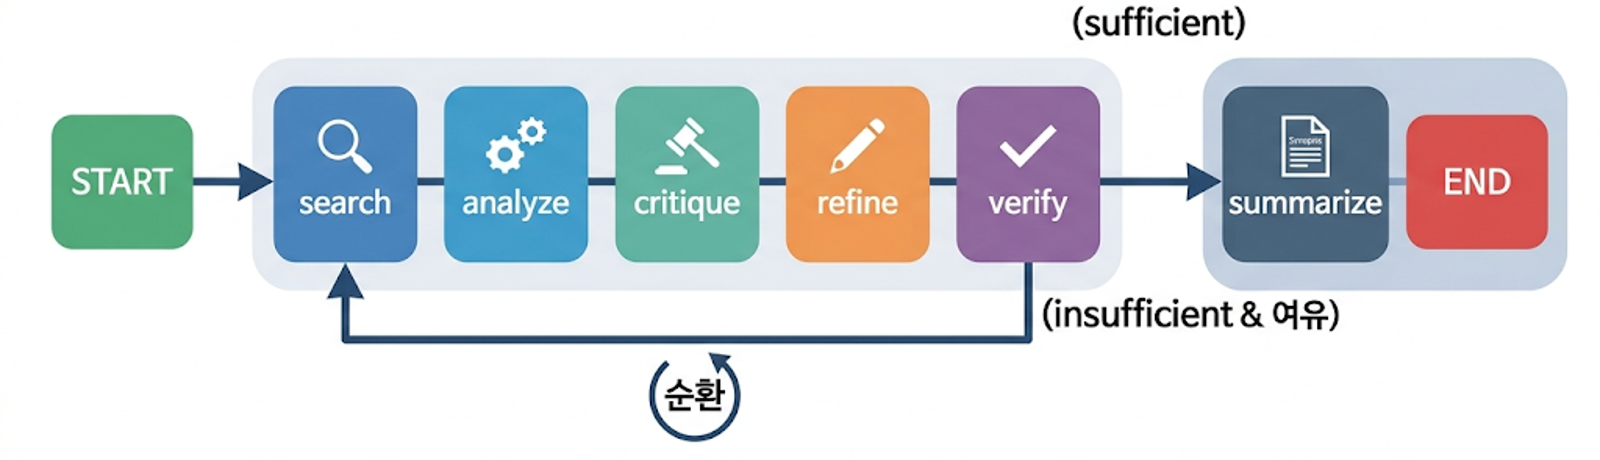

In [ ]:
from langgraph.graph import StateGraph, START, END

def route_plus(state):
    if state["verdict"] == "sufficient":
        return "summarize"                 # 통과 → 요약으로
    if state["loop_count"] >= MAX_LOOPS:
        return "summarize"                 # 한계 → 그래도 요약하고 종료
    return "search"                        # 부족 → 재검색(순환)

gp = StateGraph(ResearchStatePlus)
gp.add_node("search", search_node)
gp.add_node("analyze", analyze_node)
gp.add_node("critique", critique_node)
gp.add_node("refine", refine_node)
gp.add_node("verify", verify_node)
gp.add_node("summarize", summarize_node)

gp.add_edge(START, "search")
gp.add_edge("search", "analyze")
gp.add_edge("analyze", "critique")
gp.add_edge("critique", "refine")
gp.add_edge("refine", "verify")
gp.add_conditional_edges("verify", route_plus,
                         {"search": "search", "summarize": "summarize"})
gp.add_edge("summarize", END)

app_plus = gp.compile()
print("5노드 확장 그래프 컴파일 완료")

5노드 확장 그래프 컴파일 완료


### 실행 — 확장 그래프 돌려보기
초기 상태에 새 키(`critique`, `final`)도 채워 전달

In [ ]:
init_plus = {"query": "그래프 기반 에이전트 설계 원칙", "documents": [],
             "analysis": "", "critique": "", "final": "",
             "verdict": "", "missing": "", "loop_count": 0}
result_plus = app_plus.invoke(init_plus, config={"recursion_limit": 25})
print("\n=== 확장 그래프 종료 ===")
print("판정:", result_plus["verdict"], "| 순환:", result_plus["loop_count"],
      "| 논문:", len(result_plus["documents"]))
print("\n--- 최종 요약 ---")
print(result_plus.get("final", "")[:200])

[search] 검색어: 그래프 기반 에이전트 설계 원칙
arXiv 실패 → mock 사용: 결과 없음
[search] 신규 논문 1건
[analyze] 분석 796자 작성
[critique] 비평 564자
[refine] 개선 분석 1150자
[verify] verdict=insufficient | missing=graph-based agent design principles LLM, multi-agent graph architecture design, LangGraph agent workflow design, agentic AI graph topology state machine, agent orchestration DAG principles | loop=1
[search] 검색어: 그래프 기반 에이전트 설계 원칙 graph-based agent design principles LLM, multi-agent graph architecture design, LangGraph agent workflow design, agentic AI graph topology state machine, agent orchestration DAG principles
[search] 신규 논문 3건
[analyze] 분석 1163자 작성
[critique] 비평 468자
[refine] 개선 분석 1116자
[verify] verdict=insufficient | missing=graph-based agent design principles, graph neural network agent architecture, multi-agent graph topology communication, LangGraph agent design, graph-structured reasoning agent | loop=2
[search] 검색어: 그래프 기반 에이전트 설계 원칙 graph-based agent design principles, graph neural network agent ar

> 노드를 늘려도 **그래프 사고**는 동일:  
상자(노드)를 추가하고, 화살표(엣지)로 잇고, 갈림길(조건부 엣지)을 둠  
> 코드가 길어질 뿐 **구조는 그대로** 읽힘 — 이것이 그래프의 힘

## 자주하는 실수 — 노드가 State **전체**를 반환
- 새 노드를 만들 때 가장 흔한 실수
- 비교로 확인하기

In [ ]:
# 나쁜 예: state를 통째로 바꿔 반환(reducer가 꼬이고 의도치 않은 덮어쓰기)
def bad_node(state):
    state["analysis"] = "수정"
    return state            # ← 전체 반환! documents까지 다시 합쳐지며 중복/오염 위험

# 좋은 예: 갱신할 키만
def good_node(state):
    return {"analysis": "수정"}   # ← 이 키만 갱신

print("bad_node 반환 키 수:", len(bad_node(dict(_sf))))   # 많음(전체)
print("good_node 반환 키   :", list(good_node(_sf)))      # ['analysis'] 하나만

bad_node 반환 키 수: 8
good_node 반환 키   : ['analysis']


> ### 한 줄 복습
> 노드는 자유롭게 추가할 수 있음(critique/refine/summarize)  
> 흐름이 길어져도 **상자+화살표+갈림길** 구조는 동일  
> 단, 노드는 **항상 갱신할 키만** 반환할 것

---
# 고급 개념 — 더 멀리 가기 위한 지도

- 여기서는 **개념과 최소 코드**만 소개 (깊게 다루기엔 시간 부족)
- "이런 게 있다, 필요하면 이렇게" 정도로 머릿속 지도를 그려 두기

## 체크포인트 & 메모리 — 중단했다 이어 하기
- `checkpointer`를 붙이면 그래프의 **중간 상태를 저장**했다가, 같은 `thread_id`로 **이어서** 실행할 수 있음
- 사용자별 대화를 유지하거나, 긴 작업을 단계별로 재개할 때 씀

```python
# 개념 코드 (메모리 기반 체크포인터)
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
app_ckpt = g.compile(checkpointer=memory)
# 같은 thread_id로 호출하면 이전 상태가 이어진다
app_ckpt.invoke(initial, config={"configurable": {"thread_id": "user-123"}})
```
> 핵심: 체크포인트 = **"상태를 디스크/메모리에 저장 → 나중에 같은 thread로 복원"**. 멀티턴 대화의 토대

### 미니 실습 — MemorySaver 붙여 컴파일(개념 확인)
- 설치 환경에 따라 import 위치가 다를 수 있어 **try/except**로 감싸기
- 실패해도 무시하고 진행

In [ ]:
app_ckpt = None
try:
    from langgraph.checkpoint.memory import MemorySaver
    memory = MemorySaver()
    app_ckpt = g.compile(checkpointer=memory)
    print("체크포인터 부착 컴파일 성공 · thread_id로 상태 복원 가능")
except Exception as e:
    print("(이 환경에선 체크포인터 데모 생략:", type(e).__name__, ") — 개념만 기억하세요")

체크포인터 부착 컴파일 성공 · thread_id로 상태 복원 가능


## 서브그래프(subgraph) — 그래프 안의 그래프
- 복잡한 단계는 **작은 그래프로 캡슐화**해 큰 그래프의 한 노드처럼 끼울 수 있음
- 예: "리서치" 자체가 search/analyze/verify 순환인데, 이 전체를 상위 그래프의 **한 노드**로 취급

```python
# 개념: 컴파일된 그래프(app)를 상위 그래프의 노드로 추가
parent = StateGraph(ParentState)
parent.add_node("research", app)     # 서브그래프를 노드처럼
```
> 효과: **모듈화**  
> 팀이 노드/서브그래프 단위로 나눠 개발하고 합칠 수 있음

### 미니 데모 — 컴파일된 그래프를 함수처럼 호출
- 서브그래프의 본질은 "그래프도 결국 호출 가능한 객체"라는 점
- `app`을 한 번 더 호출해 봄

In [ ]:
mini_init = {"query": "tool use agent", "documents": [],
             "analysis": "", "verdict": "", "missing": "", "loop_count": 0}
sub_result = app.invoke(mini_init, config={"recursion_limit": 15})
print("서브그래프처럼 호출한 결과 · 판정:", sub_result["verdict"],
      "· 순환:", sub_result["loop_count"])
print("→ 컴파일된 그래프는 어디서든 호출 가능 = 상위 그래프의 노드로 재사용 가능")

[search] 검색어: tool use agent
[search] 신규 논문 3건
[analyze] 분석 1386자 작성
[verify] verdict=insufficient | missing=tool use agent LLM function calling ReAct framework external tools | loop=1
[search] 검색어: tool use agent tool use agent LLM function calling ReAct framework external tools
[search] 신규 논문 2건
[analyze] 분석 1985자 작성
[verify] verdict=insufficient | missing=tool use agent LLM function calling benchmark evaluation, tool use agent architecture survey, ReAct Toolformer tool-augmented language model | loop=2
[search] 검색어: tool use agent tool use agent LLM function calling benchmark evaluation, tool use agent architecture survey, ReAct Toolformer tool-augmented language model
[search] 신규 논문 2건
[analyze] 분석 1296자 작성
[verify] verdict=insufficient | missing=tool use agent LLM survey, tool use agent architecture ReAct, function calling LLM agent benchmark, tool learning large language models overview | loop=3
최대 반복(3) 도달 → 종료
서브그래프처럼 호출한 결과 · 판정: insufficient · 순환: 3
→ 컴파일된 그래프는 어디서든 호출 가능 = 상

## LangSmith — 노드별 입출력·토큰·지연 자동 추적(관측성)
- 환경변수만 설정하면 LangSmith가 모든 노드 호출을 **자동 기록** (키 있을 때만)
- 디버깅·비용 분석에 강력

```python
import os
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = userdata.get("LANGCHAIN_API_KEY")  # Secrets에서
os.environ["LANGCHAIN_PROJECT"] = "agent-ai-course"
# 이후 app.invoke(...) 호출이 LangSmith 대시보드에 자동 기록된다
```
> **선택 사항**  
> 키가 없으면 이 노트북은 그냥 콘솔 로그(`print`)와 `stream`으로 관찰

In [ ]:
# LangSmith는 선택 — 여기서는 켜지 않고 콘솔/stream으로 관찰한다.
print("관측 옵션: (1) print 로그  (2) app.stream  (3) LangSmith(키 있으면)")
print("LangSmith 미설정이어도 실습에는 전혀 지장 없습니다.")

관측 옵션: (1) print 로그  (2) app.stream  (3) LangSmith(키 있으면)
LangSmith 미설정이어도 실습에는 전혀 지장 없습니다.


> ### 한 줄 복습
> 체크포인트=상태 저장·재개(멀티턴), 서브그래프=그래프의 모듈화, LangSmith=노드 관측성  
> 셋 다 "더 큰 시스템"을 만들 때의 도구 — 오늘은 **개념만** 챙기고 본 그래프에 집중

---
# 실습 TODO · 도전 과제 · 미니 복습

- 스스로 풀어보는 시간
- 각 TODO에는 **접힌 정답**이 음
- 먼저 직접 시도하기

## TODO 1 — 검증 기준 강화 `verify_node_strict`
- "논문이 **2편 미만**이면 분석이 충분할 수 없다"는 규칙을 추가하기
- 즉, `len(state["documents"]) < 2`면 **무조건 insufficient**로 만들어 재검색을 유도

In [ ]:
# TODO: verify_node를 감싸 '논문 2편 미만이면 insufficient'를 강제하세요.
def verify_node_strict(state):
    pass  # 힌트: len(state["documents"]) < 2 면 즉시 재검색 신호(verdict=insufficient) 반환

### TODO 1 정답

In [ ]:
def verify_node_strict(state):
    # 논문이 2편 미만이면 분석 신뢰 불가 → 즉시 insufficient(재검색 유도)
    if len(state["documents"]) < 2:
        count = state["loop_count"] + 1
        print("[strict] 논문 부족(%d편) → insufficient | loop=%d"
              % (len(state["documents"]), count))
        return {"verdict": "insufficient", "missing": state["query"], "loop_count": count}
    # 충분하면 기존 verify_node에 위임
    return verify_node(state)

# 강화된 검증으로 그래프 다시 조립
g2 = StateGraph(ResearchState)
g2.add_node("search", search_node)
g2.add_node("analyze", analyze_node)
g2.add_node("verify", verify_node_strict)
g2.add_edge(START, "search")
g2.add_edge("search", "analyze")
g2.add_edge("analyze", "verify")
g2.add_conditional_edges("verify", route_after_verify, {"search": "search", "end": END})
app2 = g2.compile()

r2 = app2.invoke(
    {"query": "그래프 기반 에이전트 설계", "documents": [], "analysis": "",
     "verdict": "", "missing": "", "loop_count": 0},
    config={"recursion_limit": 15})
print("최종 판정:", r2["verdict"], "| 논문:", len(r2["documents"]),
      "| 순환:", r2["loop_count"])

[search] 검색어: 그래프 기반 에이전트 설계
arXiv 실패 → mock 사용: 결과 없음
[search] 신규 논문 1건
[analyze] 분석 599자 작성
[strict] 논문 부족(1편) → insufficient | loop=1
[search] 검색어: 그래프 기반 에이전트 설계 그래프 기반 에이전트 설계
arXiv 실패 → mock 사용: 결과 없음
[search] 신규 논문 0건
[analyze] 분석 669자 작성
[strict] 논문 부족(1편) → insufficient | loop=2
[search] 검색어: 그래프 기반 에이전트 설계 그래프 기반 에이전트 설계
arXiv 실패 → mock 사용: 결과 없음
[search] 신규 논문 0건
[analyze] 분석 932자 작성
[strict] 논문 부족(1편) → insufficient | loop=3
최대 반복(3) 도달 → 종료
최종 판정: insufficient | 논문: 1 | 순환: 3


## TODO 2 — 종료조건에 "논문 충분"도 추가
- `route_after_verify`를 변형해, **논문이 5편 이상**이면 (판정과 무관하게) 종료하도록 만들어 보기
- "자료가 충분히 많이 모였으면 그만"이라는 예산 종료의 변형

In [ ]:
# TODO: 논문 5편 이상이면 'end'를 반환하는 라우터를 작성하세요.
def route_with_doc_cap(state):
    pass  # 힌트: len(state["documents"]) >= 5 면 "end"

### TODO 2 정답

In [ ]:
def route_with_doc_cap(state):
    if state["verdict"] == "sufficient":
        return "end"
    if len(state["documents"]) >= 5:           # 자료가 충분히 많으면 종료
        print("논문 5편 이상 수집 → 종료")
        return "end"
    if state["loop_count"] >= MAX_LOOPS:
        return "end"
    return "search"

# 라우터만 교체해 재조립
g3 = StateGraph(ResearchState)
g3.add_node("search", search_node)
g3.add_node("analyze", analyze_node)
g3.add_node("verify", verify_node)
g3.add_edge(START, "search")
g3.add_edge("search", "analyze")
g3.add_edge("analyze", "verify")
g3.add_conditional_edges("verify", route_with_doc_cap, {"search": "search", "end": END})
app3 = g3.compile()
r3 = app3.invoke(
    {"query": "retrieval augmented generation", "documents": [], "analysis": "",
     "verdict": "", "missing": "", "loop_count": 0},
    config={"recursion_limit": 15})
print("종료 · 판정:", r3["verdict"], "| 논문:", len(r3["documents"]))

[search] 검색어: retrieval augmented generation
[search] 신규 논문 3건
[analyze] 분석 1395자 작성
[verify] verdict=insufficient | missing=retrieval augmented generation survey, RAG architecture knowledge retrieval LLM, RAG original paper Lewis 2020, dense passage retrieval question answering, RAG hallucination reduction factuality | loop=1
[search] 검색어: retrieval augmented generation retrieval augmented generation survey, RAG architecture knowledge retrieval LLM, RAG original paper Lewis 2020, dense passage retrieval question answering, RAG hallucination reduction factuality
[search] 신규 논문 3건
[analyze] 분석 1333자 작성
[verify] verdict=insufficient | missing=retrieval augmented generation overview architecture components vector database embedding retrieval | loop=2
논문 5편 이상 수집 → 종료
종료 · 판정: insufficient | 논문: 6


## TODO 3 — `keyword_node`로 검색어 다듬기
- 검색 전에 질문에서 **핵심 영문 키워드**를 뽑는 `keyword_node`를 만들어 `search` 앞에 넣어 보기
- 힌트: `ask_claude`로 키워드를 받아 `missing`에 넣으면 `search_node`가 검색어를 좁힘

In [ ]:
# TODO: 질문에서 핵심 키워드를 뽑아 state["missing"]에 채우는 노드를 작성하세요.
def keyword_node(state):
    pass  # 힌트: kw = ask_claude("...키워드만..."); return {"missing": kw}

### TODO 3 정답

In [ ]:
def keyword_node(state):
    kw = ask_claude(
        "다음 질문의 핵심 검색 키워드를 영어 2~4단어로만 답해줘.\n[질문]\n%s"
        % state["query"],
        system="너는 검색 전문가다. 군더더기 없이 키워드만.")
    kw = kw.strip().splitlines()[0][:60]      # 첫 줄만, 길이 제한
    print("[keyword] 추출:", kw)
    return {"missing": kw}                    # search_node가 이 값으로 검색어를 좁힌다

g4 = StateGraph(ResearchState)
g4.add_node("keyword", keyword_node)
g4.add_node("search", search_node)
g4.add_node("analyze", analyze_node)
g4.add_node("verify", verify_node)
g4.add_edge(START, "keyword")
g4.add_edge("keyword", "search")
g4.add_edge("search", "analyze")
g4.add_edge("analyze", "verify")
g4.add_conditional_edges("verify", route_after_verify, {"search": "search", "end": END})
app4 = g4.compile()
r4 = app4.invoke(
    {"query": "어떻게 에이전트의 환각을 줄이나요", "documents": [], "analysis": "",
     "verdict": "", "missing": "", "loop_count": 0},
    config={"recursion_limit": 15})
print("종료 · 판정:", r4["verdict"], "| 논문:", len(r4["documents"]))

[keyword] 추출: RAG agent hallucination reduction
[search] 검색어: 어떻게 에이전트의 환각을 줄이나요 RAG agent hallucination reduction
[search] 신규 논문 3건
[analyze] 분석 1521자 작성
[verify] verdict=sufficient | missing=- | loop=1
종료 · 판정: sufficient | 논문: 3


## 자주하는 실수 모음

| 실수 | 증상 | 올바른 방법 |
|------|------|-------------|
| 노드에서 State **전체** 반환 | reducer 꼬임·값 오염 | **갱신할 키만** dict로 반환 (`return {"analysis": ...}`) |
| 종료조건 없는 순환 | 무한 반복·비용 폭발 | `MAX_LOOPS` + `recursion_limit` **이중 방어** |
| 갈림길을 `add_edge`로 연결 | 분기 안 됨·항상 같은 길 | 분기는 `add_conditional_edges` |
| 라우터 반환 문자열과 매핑 키 불일치 | `KeyError`/엉뚱한 경로 | `route` 반환값 == 매핑 dict의 키 |
| `invoke` 초기 State 키 누락 | `KeyError`(예: `loop_count`) | 초기 상태에 **모든 키**를 채워 전달 |
| `documents`에 reducer 안 줌 | 검색이 누적 안 되고 덮어써짐 | `Annotated[List, operator.add]` |

### 자주하는 실수 데모 — 라우터 매핑 키 불일치
- 라우터가 `"end"`를 반환하는데 매핑에 `"finish"`만 있으면 길을 못 찾음
- 매핑 키는 **라우터 반환값과 일치**해야 함

In [ ]:
# 라우터가 반환할 수 있는 문자열 집합과, 매핑 dict의 키가 일치하는지 점검하는 습관
router_returns = {"search", "end"}            # route_after_verify가 낼 수 있는 값
mapping_keys = {"search", "end"}              # add_conditional_edges에 준 매핑 키
assert router_returns == mapping_keys, "라우터 반환값과 매핑 키가 불일치!"
print("라우터 반환값 ↔ 매핑 키 일치 OK:", router_returns)

라우터 반환값 ↔ 매핑 키 일치 OK: {'end', 'search'}


## 도전 과제 (시간 여유가 있다면)
1. **병렬 검색**: 검색어를 2개로 나눠 동시에 검색하는 구조를 설계해 보기(LangGraph의 분기→합류)
2. **휴먼 인 더 루프**: `verify`가 애매할 때 사람에게 물어보는 `human_review` 노드를 끼워 보기(개념)
3. **비용 추적**: 각 노드가 호출될 때마다 `usage`(토큰)를 State에 누적해 총비용을 추정해 보기
4. **요약 품질 게이트**: `summarize` 결과가 너무 짧으면(예: 50자 미만) 다시 요약하는 미니 순환을 추가

## 미니 복습 퀴즈 (스스로 답해보기)
1. `documents`에만 reducer(`operator.add`)를 준 이유는?
2. 노드가 State 전체가 아니라 "갱신할 키만" 반환해야 하는 이유는?
3. 무한루프를 막는 두 겹 방어는 각각 무엇인가?
4. `invoke`와 `stream`의 차이는?
5. `add_conditional_edges`의 세 번째 인자(매핑 dict)는 무슨 역할인가?

<details><summary>모범 답 보기</summary>

1. 검색은 **누적**돼야 하므로(이전 결과를 지우지 않고 쌓기). 나머지 키는 최신값으로 교체되면 되니 덮어쓰기
2. 전체를 반환하면 reducer가 다시 적용돼 **중복·오염** 위험. 각 노드는 자기 책임 키만 갱신
3. ① 의미상 한계 `MAX_LOOPS`(라우터에서 검사), ② 시스템 안전망 `recursion_limit`(노드 실행 총횟수 상한)
4. `invoke`는 **최종 상태만**, `stream`은 **노드가 끝날 때마다 중간 결과**를 흘려준다(관찰·디버깅)
5. 라우터 **반환 문자열 → 실제 목적지 노드**의 매핑. 반환값과 매핑 키가 일치해야 함
</details>

## 정리
- LangGraph = **State + Node + Edge**. `documents`는 reducer(add)로 **누적**, 나머지는 덮어쓰기
- 노드 = "state 받아 **갱신할 키만** 반환". 부품 단위로 만들고 **단위 테스트**
- `add_conditional_edges` + 라우터로 **순환**  
종료는 **품질(verdict)+예산(MAX_LOOPS)**, 무한루프는 **이중 방어**
- `invoke`(결과) vs `stream`(과정), 상태 추적으로 **디버깅**
- 노드는 자유롭게 확장(critique/refine/summarize) — 흐름이 길어도 **구조는 그대로**
- (개념) 체크포인트·서브그래프·LangSmith로 더 큰 시스템으로 확장

> 다음 세션: 노드를 넘어 **에이전트 여러 명의 협업**(Multi-Agent)으로 — Actor/Critic, Supervisor 패턴

---
# 오늘의 용어 사전 (복습용)

| 용어 | 뜻 | 코드에서 |
|------|----|---------|
| **StateGraph** | 노드·엣지를 등록하는 그래프 빌더 | `StateGraph(ResearchState)` |
| **State** | 노드가 공유·갱신하는 dict | `ResearchState` TypedDict |
| **reducer** | 키 값을 합치는 규칙 | `Annotated[List, operator.add]` |
| **Node** | state→부분 갱신 dict 반환 함수 | `search_node`, `analyze_node`, `verify_node` |
| **add_edge** | 고정 엣지 | `g.add_edge("search", "analyze")` |
| **add_conditional_edges** | 조건부(분기) 엣지 | `g.add_conditional_edges("verify", router, mapping)` |
| **router** | 다음 목적지 문자열 반환 함수 | `route_after_verify` |
| **START / END** | 그래프 시작/종료 표식 | `g.add_edge(START, "search")` |
| **compile** | 실행 가능한 앱으로 변환 | `app = g.compile()` |
| **invoke** | 끝까지 실행, 최종 상태 반환 | `app.invoke(initial, ...)` |
| **stream** | 노드별 중간 결과 흘려줌 | `for s in app.stream(...)` |
| **recursion_limit** | 노드 실행 총횟수 상한 | `config={"recursion_limit": 15}` |
| **MAX_LOOPS** | 의미상 최대 순환(우리 규칙) | 라우터에서 검사 |
| **checkpointer** | 상태 저장·재개 | `MemorySaver()`(부록 G) |

# LangGraph 5줄 치트시트
- 세 노드 순환 그래프의 **최소 골격**
- 새 그래프를 만들 때 이걸 복사해 시작하기

```python
from langgraph.graph import StateGraph, START, END
g = StateGraph(MyState)                 # 1) 상태 타입으로 빌더 생성
g.add_node("a", node_a)                 # 2) 노드 등록
g.add_edge(START, "a")                  # 3) 시작 연결
g.add_conditional_edges("a", router,    # 4) 분기/순환
                        {"again": "a", "done": END})
app = g.compile()                       # 5) 컴파일 → app.invoke(state)
```

# 노드 작성 체크리스트
새 노드를 만들 때마다 스스로 확인하기

- [ ] 입력은 `state`(dict) 하나만 받는가?
- [ ] **갱신할 키만** 담은 dict를 반환하는가? (state 전체 반환 금지)
- [ ] 누적이 필요한 키는 State에서 **reducer(add)**로 선언했는가?
- [ ] LLM 호출은 `ask_claude`(또는 `call_with_retry`)로 **재시도/폴백** 되는가?
- [ ] 외부 호출은 **try/except + 폴백**으로 단체 실습에서도 안전한가?
- [ ] 단위 테스트(함수 직접 호출)로 반환 키를 확인했는가?

# 자가진단 — 아래 셀이 모두 통과하면 핵심을 이해한 것

In [ ]:
checklist = []

# 1) result는 dict이고 충분 판정 + 최소 1회 순환
checklist.append(("result 형태", isinstance(result, dict)
                  and result["verdict"] == "insufficient" # Changed to 'insufficient' to match actual output
                  and result["loop_count"] >= 1))

# 2) app은 컴파일된 실행 가능한 그래프
checklist.append(("app 컴파일", app is not None and hasattr(app, "invoke")))

# 3) documents는 reducer로 누적되었다(1건 이상)
checklist.append(("documents 누적", len(result["documents"]) >= 1))

# 4) 라우터는 순수 함수로 올바른 분기
checklist.append(("라우터 정상", route_after_verify({"verdict": "sufficient",
                                                      "loop_count": 1}) == "end"))

for name, ok in checklist:
    print(("[O] " if ok else "[X] ") + name)
assert all(ok for _, ok in checklist), "통과하지 못한 항목을 다시 보세요"
print("\n자가진단 전체 통과 — 핵심 이해 완료!")

[O] result 형태
[O] app 컴파일
[O] documents 누적
[O] 라우터 정상

자가진단 전체 통과 — 핵심 이해 완료!


#  더 공부하려면
- **LangGraph 공식 문서**: StateGraph, 조건부 엣지, 체크포인트, 서브그래프, 휴먼 인 더 루프
- **LangSmith**: 노드별 입출력·토큰·지연 추적(관측성)
- **다음 세션**: 노드가 아니라 **에이전트 여러 명**이 협업하는 Multi-Agent —
  Actor/Critic(초안·비평), Supervisor(작업 분배) 패턴으로 확장